In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd
import os
import gc
import sys

sys.path.insert(0, '..')
from src import *

In [6]:
#path = '../data/convergence/dt0.002'
path = '../data/convergence/dt0.005'
#path = '../data/convergence/gpu_dt0.002'
data = Data(path)
dataset = data.read(['thermo', 'press', 'press_pot', 'born', 'born_nl'])
thermo_data, press_data, press_pot_data, born_data, born_nl_data = dataset.values()
scale = data.get_scale()

In [7]:
# debug
# min_len = np.min([len(thermo_data), len(press_data), len(born_data), len(press_pot_data)])
# thermo_data = thermo_data[:min_len]
# press_data = press_data[:min_len]
# press_pot_data = press_pot_data[:min_len]
# born_data = born_data[:min_len]

dt = thermo_data.time[1] - thermo_data.time[0]
time = thermo_data.time

In [9]:
data2 = Data('../data/convergence/dt0.002')
thermo_data2 = data2.read(['thermo'])['thermo']

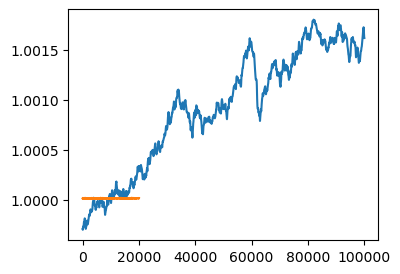

In [12]:
plt.figure(figsize=(4,3))
plt.plot(thermo_data.time, sp.ndimage.gaussian_filter(
    thermo_data.energy/thermo_data.energy[0], 100))
mask = thermo_data2.time>-1
plt.plot(thermo_data2.time[mask], sp.ndimage.gaussian_filter(
    thermo_data2.energy[mask]/thermo_data2.energy[0], 100))

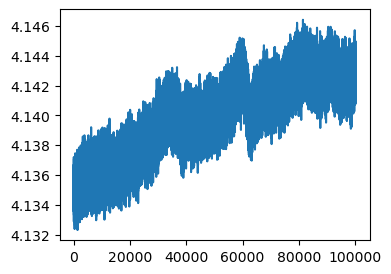

In [27]:
plt.figure(figsize=(4,3))
plt.plot(thermo_data.time, thermo_data.energy)

In [13]:
# create 2nd and 4th order tensors out of pressure (stress) and born data
press_raw = np.array(press_data.iloc[:,2:]) * scale
stress = -lammps_array_to_matrix(press_raw)
stress_d = stress - stress.mean(axis=0)
press_avg = -np.trace(stress.mean(axis=0)) / 3
# N = stress_d.shape[0]

press_pot_raw = np.array(press_pot_data.iloc[:,2:]) * scale
press_kin_raw = press_raw - press_pot_raw
stress_kin = -lammps_array_to_matrix(press_kin_raw)
stress_kin_mean = stress_kin.mean(axis=0)

born_raw = np.array(born_data.iloc[:,2:]) * scale / thermo_data.vol[0]
born_voigt = lammps_array_to_matrix(born_raw)
CB = voigt_to_tensor(born_voigt)
CB_avg = CB.mean(axis=0)
CK = -4 * sym_dyad(np.eye(3), stress_kin)
CBK = CB + CK
CBK_avg = CBK.mean(axis=0)

born_nl_raw = np.array(born_nl_data.iloc[:,2:]) * scale / thermo_data.vol[0]
born_nl_voigt = lammps_array_to_matrix(born_nl_raw.reshape(len(born_nl_raw), 21, 6).swapaxes(-1, -2))
NB_avg = voigt_to_tensor(born_nl_voigt, order=3).mean(axis=0)
NK_avg = -sym_dyad(np.eye(3), CBK_avg) / 8
NK_avg += NK_avg.swapaxes(0, 2).swapaxes(1,3) + NK_avg.swapaxes(0, 4).swapaxes(1,5)
NBK_avg = NB_avg + NK_avg

In [14]:
def major_symmetry6(tens):
    tens_t = np.swapaxes(np.swapaxes(tens, -6, -4), -5, -3)
    print('ij<->kl:', np.linalg.norm(tens - tens_t))
    tens_t = np.swapaxes(np.swapaxes(tens, -3, -1), -4, -2)
    print('kl<->mn:', np.linalg.norm(tens - tens_t))
    tens_t = np.swapaxes(np.swapaxes(tens, -6, -2), -5, -1)
    print('ij<->mn:', np.linalg.norm(tens - tens_t))

print('NK:')
major_symmetry6(NK_avg)

print('NB:')
major_symmetry6(NB_avg)

NK:
ij<->kl: 2.0097183471755504e-14
kl<->mn: 0.0
ij<->mn: 2.0097183471755504e-14
NB:
ij<->kl: 0.24286835389730985
kl<->mn: 0.0
ij<->mn: 0.24286835389730985


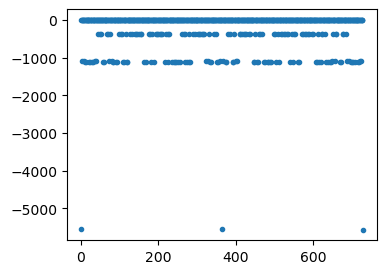

In [15]:
plt.figure(figsize=(4,3))
plt.plot(NBK_avg.flatten(), '.')

In [16]:
gc.collect()

5930

## Nonlinear moduli

### Individual

In [18]:
stress_d.shape

(200101, 3, 3)

In [21]:
def CBK_stress_term(CBK, stress, born_len, V, T, ind=(0,0,0,0,0,0)):
    i,j,k,l,m,n = ind
    return - V/(2*T) * (CBK[:,i,j,k,l] * stress[:born_len,m,n] + 
                        CBK[:,i,j,m,n] * stress[:born_len,k,l] +
                        CBK[:,k,l,m,n] * stress[:born_len,i,j])

def stress3_term(stress, born_len, V, T, ind=(0,0,0,0,0,0)):
    i,j,k,l,m,n = ind
    return V**2 / (2*T**2) * (stress_d[:,i,j] * stress_d[:,k,l] * stress_d[:,m,n])

born_len = len(born_data)

In [22]:
#i, j, k, l, m, n = 0, 1, 2, 1, 0, 2
#i, j, k, l, m, n = 0,2,0,2,0,2
ind = 0,0,0,0,0,0
#ind = 1,1,1,1,1,1
#ind = 2,2,2,2,2,2
V = thermo_data.vol.mean()
T = thermo_data.temp.mean()

CBK_stress = CBK_stress_term(CBK, stress_d, born_len, V, T, ind).mean(0)
stress3 = stress3_term(stress_d, born_len, V, T, ind).mean(0)
modulus_stat = NBK_avg[*ind] + CBK_stress + stress3

print(f'NBK:   {NBK_avg[*ind]:7.1f}')
print(f'Corr2: {CBK_stress:7.1f}')
print(f'Corr3: {stress3:7.1f}\n')
print(f'NBK+corr2: {NBK_avg[*ind]+CBK_stress:7.1f}')
print(f'pressure:  {press_avg:7.1f}')

NBK:   -5549.9
Corr2:  3439.6
Corr3: -1219.2

NBK+corr2: -2110.3
pressure:     34.9


In [23]:
def convergence(arr, pnum=10):
    last_ind = np.array(np.logspace(1, np.log10(len(arr)), num=pnum), dtype=int)
    res = np.zeros_like(last_ind, dtype=float)
    for ind, li in enumerate(last_ind):
        res[ind] = (arr[:li]).mean()
    return res, last_ind    

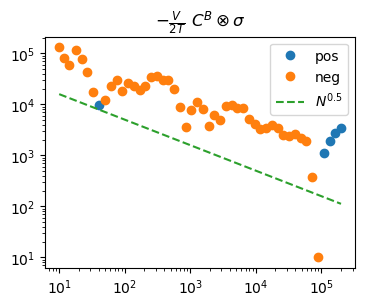

In [24]:
CBKsigma, last_ind = convergence(CBK_stress_term(CBK, stress_d, born_len, V, T, ind), pnum=50)
mask = CBKsigma > 0
plt.figure(figsize=(4,3))
plt.plot(last_ind[mask], CBKsigma[mask], 'o', label='pos')
plt.plot(last_ind[np.logical_not(mask)], -CBKsigma[np.logical_not(mask)], 'o', label='neg')
plt.plot(last_ind, last_ind**(-1/2) * 5e4, '--', label=r'$N^{0.5}$')
plt.legend()
plt.title(r'$-\frac{V}{2T}\ C^B \otimes \sigma$')
plt.xscale('log')
plt.yscale('log')

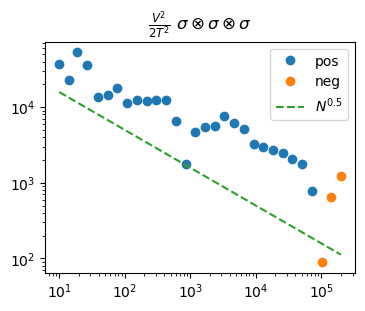

In [25]:
sigma3mean, last_ind = convergence(stress3_term(stress_d, born_len, V, T, ind), pnum=30)
mask = sigma3mean > 0
plt.figure(figsize=(4,3))
plt.plot(last_ind[mask], sigma3mean[mask], 'o', label='pos')
plt.plot(last_ind[np.logical_not(mask)], -sigma3mean[np.logical_not(mask)], 'o', label='neg')
plt.plot(last_ind, last_ind**(-1/2) * 5e4, '--', label=r'$N^{0.5}$')
plt.legend()
plt.title(r'$\frac{V^2}{2T^2}\ \sigma \otimes \sigma \otimes \sigma$')
plt.xscale('log')
plt.yscale('log')

In [26]:
modulus_stat

np.float64(-3329.5226806667806)

### All of them

In [27]:
V = thermo_data.vol.mean()
T = thermo_data.temp.mean()
N_qs = np.zeros((3,)*6)
N_qs_corr2 = np.zeros_like(N_qs)
N_qs_corr3 = np.zeros_like(N_qs)

for i in range(3):
    for j in range(3):
        for k in range(3):
            for l in range(3):
                for m in range(3):
                    for n in range(3):
                        _ind = i,j,k,l,m,n
                        N_qs_corr2[*_ind] = CBK_stress_term(CBK, stress_d, born_len, V, T, _ind).mean(0)
                        N_qs_corr3[*_ind] = stress3_term(stress_d, born_len, V, T, _ind).mean(0)
                        N_qs[*_ind] = (NBK_avg + N_qs_corr2 + N_qs_corr3)[*_ind]

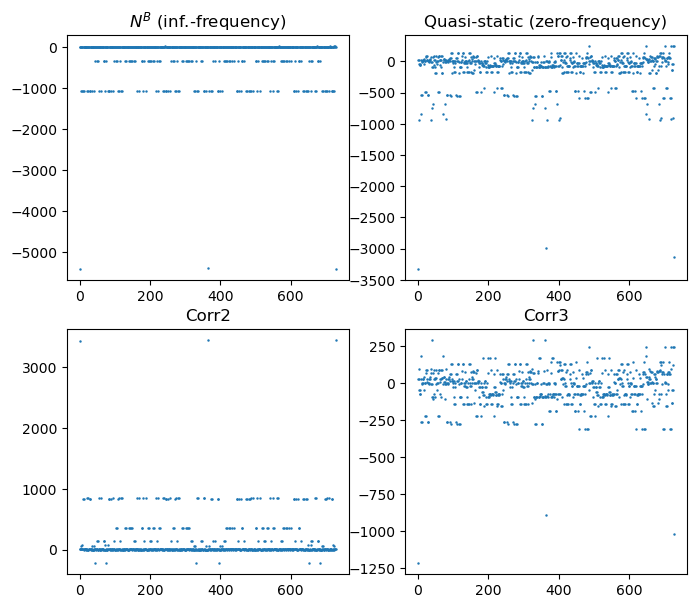

In [28]:
fig, ax = plt.subplots(2,2, figsize=(8,7))
ax[0,0].set_title(r'$N^B$ (inf.-frequency)')
ax[0,0].plot(NB_avg.flatten(), '.', ms=1.5)
ax[0,1].set_title('Quasi-static (zero-frequency)')
ax[0,1].plot(N_qs.flatten(), '.', ms=1.5)

ax[1,0].set_title('Corr2')
ax[1,0].plot(N_qs_corr2.flatten(), '.', ms=1.5)
ax[1,1].set_title('Corr3')
ax[1,1].plot(N_qs_corr3.flatten(), '.', ms=1.5)

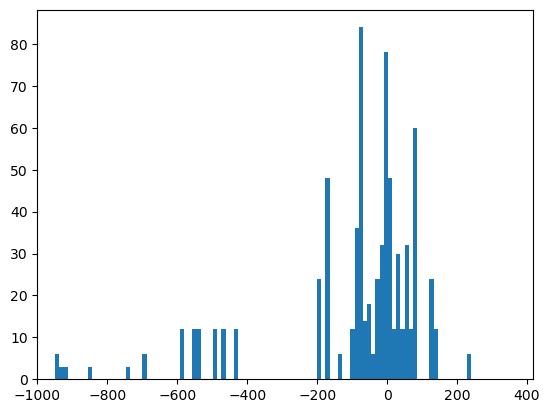

In [30]:
plt.hist(N_qs.flatten(), bins=300)
plt.xlim(-1000, None)
plt.show()

### Correlation

In [31]:
stress_d.shape

(200101, 3, 3)

In [32]:
#s = stress_d[:3000:10,0,0]
s3 = 0
step_size = 50
steps = len(stress_d)//step_size-1
for i in range(steps):
    #print(i)
    s = stress_d[step_size*i:step_size*(i+2),0,1].copy()
    #s -= s.mean()
    s3 += corr3_fast(s).real / steps

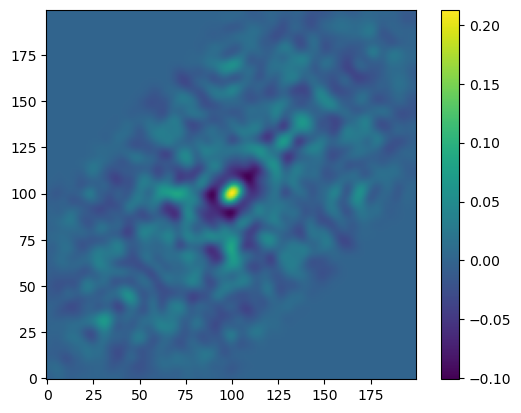

In [33]:
data = V**2 / 2 / T**2 * np.fft.fftshift(s3.T)
plt.imshow(sp.ndimage.gaussian_filter(data, 3), origin='lower')
plt.colorbar()

## Stress distribution

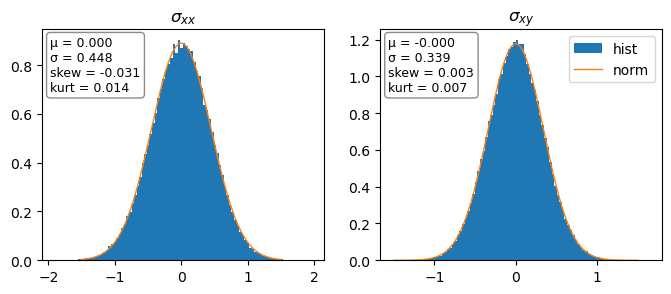

In [34]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
x = np.linspace(-1.5, 1.5, num=200)

arr = stress_d[:,0,0]
ax[0].set_title(r"$\sigma_{xx}$")
ax[0].hist(arr, density=True, bins=100)
ax[0].plot(x, sp.stats.norm.pdf(x, arr.mean(), arr.std()), lw=1)
stats_text = f'μ = {arr.mean():.3f}\nσ = {arr.std():.3f}\n\
skew = {sp.stats.skew(arr):.3f}\nkurt = {sp.stats.kurtosis(arr):.3f}'
ax[0].text(0.03, 0.97, stats_text, transform=ax[0].transAxes,
           verticalalignment='top', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
           fontsize=9)

arr = stress_d[:,0,1]
ax[1].set_title(r"$\sigma_{xy}$")
ax[1].hist(arr, density=True, bins=100, label='hist')
ax[1].plot(x, sp.stats.norm.pdf(x, arr.mean(), arr.std()), lw=1, label='norm')
ax[1].legend()
stats_text = f'μ = {arr.mean():.3f}\nσ = {arr.std():.3f}\n\
skew = {sp.stats.skew(arr):.3f}\nkurt = {sp.stats.kurtosis(arr):.3f}'
ax[1].text(0.03, 0.97, stats_text, transform=ax[1].transAxes,
           verticalalignment='top', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
           fontsize=9)

#fig.savefig("sigma_dist.png")
plt.show()

In [35]:
sp.stats.skewtest(stress_d[:,0,1])

SkewtestResult(statistic=np.float64(0.6345093052556706), pvalue=np.float64(0.5257484960143872))

In [36]:
sp.stats.skewtest(stress_d[:,0,0])

SkewtestResult(statistic=np.float64(-5.611133416903423), pvalue=np.float64(2.0100571499085806e-08))

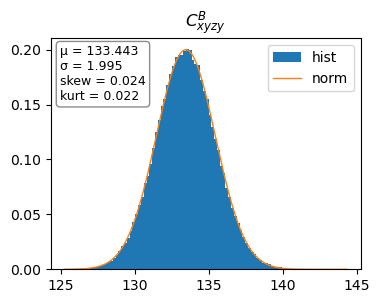

In [37]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
i,j,k,l = 0,1,0,1
arr = CB[:,i,j,k,l]
x = np.linspace(arr.min(), arr.max(), num=200)

ax.set_title(r"$C^B_{xyzy}$")
ax.hist(arr, density=True, bins=100, label='hist')
ax.plot(x, sp.stats.norm.pdf(x, arr.mean(), arr.std()), lw=1, label='norm')
ax.legend()
stats_text = f'μ = {arr.mean():.3f}\nσ = {arr.std():.3f}\n\
skew = {sp.stats.skew(arr):.3f}\nkurt = {sp.stats.kurtosis(arr):.3f}'
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
           fontsize=9)
plt.show()

In [38]:
sp.stats.skewtest(CB[:,i,j,k,l])

SkewtestResult(statistic=np.float64(4.438195835809562), pvalue=np.float64(9.071606390390434e-06))

In [39]:
arr = V**2 / (2*T**2) * (stress_d[:,i,j] * stress_d[:,k,l] * stress_d[:,m,n])
sp.stats.skewtest(arr)

SkewtestResult(statistic=np.float64(-6.113734633702351), pvalue=np.float64(9.732609736112685e-10))

In [146]:
arr = V/(2*T) * (CBK[:,i,j,k,l] * stress_d[:,m,n] + 
                 CBK[:,i,j,m,n] * stress_d[:,k,l] +
                 CBK[:,k,l,m,n] * stress_d[:,i,j])
sp.stats.skewtest(arr)

SkewtestResult(statistic=np.float64(-124.76961270563021), pvalue=np.float64(0.0))

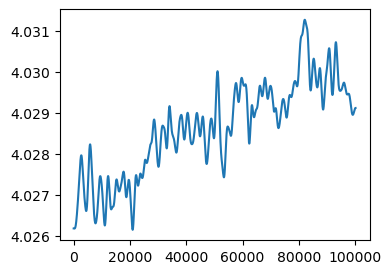

In [56]:
plt.figure(figsize=(4,3))
plt.plot(thermo_data.time, sp.ndimage.gaussian_filter(thermo_data.temp, 1000))

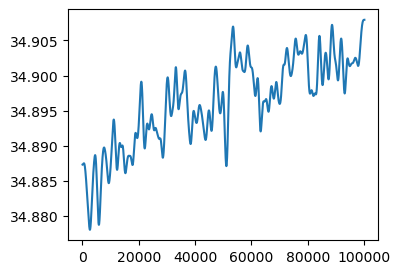

In [57]:
plt.figure(figsize=(4,3))
plt.plot(thermo_data.time, sp.ndimage.gaussian_filter((press_data.xx+press_data.yy+press_data.zz)/3, 1000))

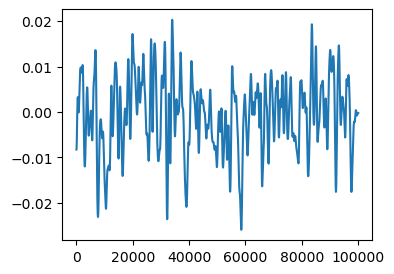

In [58]:
plt.figure(figsize=(4,3))
plt.plot(thermo_data.time, sp.ndimage.gaussian_filter(press_data.xy, 500))